<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Space X  Falcon 9 First Stage Landing Prediction**


## Hands on Lab: Complete the Machine Learning Prediction lab


Estimated time needed: **60** minutes


Space X advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because Space X can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against space X for a rocket launch.   In this lab, you will create a machine learning pipeline  to predict if the first stage will land given the data from the preceding labs.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planed. Space X; performs a controlled landing in the oceans.


## Objectives


Perform exploratory  Data Analysis and determine Training Labels

*   create a column for the class
*   Standardize the data
*   Split into training data and test data

\-Find best Hyperparameter for SVM, Classification Trees and Logistic Regression

*   Find the method performs best using test data


## Import Libraries and Define Auxiliary Functions


In [6]:
# Install standard packages using the notebook cell escape
!pip install numpy pandas scikit-learn seaborn matplotlib

We will import the following libraries for the lab


In [8]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

This function is to plot the confusion matrix.


In [9]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

## Load the dataframe


Load the data


In [12]:
URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
data = pd.read_csv(URL1)

In [13]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [14]:
URL2 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv'
X = pd.read_csv(URL2)

In [15]:
X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
88,89.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


## TASK  1


Create a NumPy array from the column <code>Class</code> in <code>data</code>, by applying the method <code>to_numpy()</code>  then
assign it  to the variable <code>Y</code>,make sure the output is a  Pandas series (only one bracket df\['name of  column']).


In [16]:
# Select the column as a Series and convert it to a NumPy array
Y = data['Class'].to_numpy()
Y[0:5]

array([0, 0, 0, 0, 0], dtype=int64)

## TASK  2


Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.


In [17]:
# students get this 
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
transform = preprocessing.StandardScaler()
scaler = StandardScaler()
X = transform.fit_transform(X)
X[0:2]



array([[-1.71291154e+00, -1.94814463e-16, -6.53912840e-01,
        -1.57589457e+00, -9.73440458e-01, -1.05999788e-01,
        -1.05999788e-01, -6.54653671e-01, -1.05999788e-01,
        -5.51677284e-01,  3.44342023e+00, -1.85695338e-01,
        -3.33333333e-01, -1.05999788e-01, -2.42535625e-01,
        -4.29197538e-01,  7.97724035e-01, -5.68796459e-01,
        -4.10890702e-01, -4.10890702e-01, -1.50755672e-01,
        -7.97724035e-01, -1.50755672e-01, -3.92232270e-01,
         9.43398113e+00, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.50755672e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.50755672e-01, -1.05999788e-0

We split the data into training and testing data using the  function  <code>train_test_split</code>.   The training data is divided into validation data, a second set used for training  data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.


## TASK  3


Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to  0.2 and random_state to 2. The training data and test data should be assigned to the following labels.


<code>X_train, X_test, Y_train, Y_test</code>


In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)
print('train size is: ',X_train.shape[0])
print('test size is: ', X_test.shape[0])

train size is:  72
test size is:  18


we can see we only have 18 test samples.


In [19]:
Y_test.shape

(18,)

## TASK  4: logistic regression


Create a logistic regression object  then create a  GridSearchCV object  <code>logreg_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [30]:
# 1. Define the parameter dictionary 
parameters ={'C':[0.01,0.1,1],
             'penalty':['l2'],
             'solver':['lbfgs']}

In [31]:
parameters ={"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}# l1 lasso l2 ridge
#  Create the logistic regression object
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)


We output the <code>GridSearchCV</code> object for logistic regression. We display the best parameters using the data attribute <code>best_params\_</code> and the accuracy on the validation data using the data attribute <code>best_score\_</code>.


In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
# Create the GridSearchCV object with cv = 10
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator=lr, param_grid=parameters, cv=10)
#  Fit the object to the training data
logreg_cv = grid_search.fit(X_train, Y_train)

# Output the best parameters and the best score
print("Tuned hpyerparameters: (best parameters)", logreg_cv.best_params_)
print("Best Accuracy Score :", logreg_cv.best_score_)


Tuned hpyerparameters: (best parameters) {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Accuracy Score : 0.8464285714285713


## TASK  5: Calculate the accuracy on the test data using logistic Regression


Calculate the accuracy on the test data using the method <code>score</code>:


In [33]:
# Calculate the accuracy score on the test data
logreg_score= logreg_cv.score(X_test, Y_test)
print(f"Test Data Accuracy: {logreg_score:.2f}")

Test Data Accuracy: 0.83


Lets look at the confusion matrix:


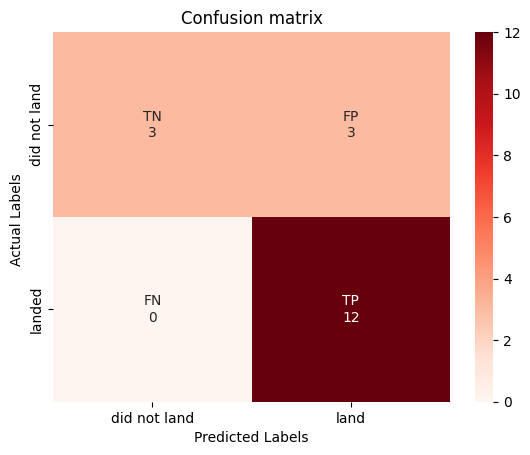

In [34]:
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

NB: The event we are usually trying to detect or predict is considered the Positive class. Here, predicting a successful landing (land) is our Positive class, and did not land is our Negative class. Examining the confusion matrix, we see that logistic regression can distinguish between the different classes. We see that the problem is false positives.
Overview:
- True Postive - 12 (True label is landed, Predicted label is also landed)
- False Postive - 3 (True label is not landed, Predicted label is landed)

The matrix above showed that:

1. True Positive (TP) = 12
     - Interpretation: The model predicted the rocket would land, and it actually landed. These are 12 perfectly correct predictions of successful landings.
2. True Negative (TN) = 3
      - Interpretation: The model predicted the rocket did not land, and it actually did not land. These are 3 correct predictions of failed landings.
3. False Positive (FP) = 3
      - Interpretation: The model predicted the rocket would land, but it actually did not land. This is a false alarm expecting a successful landing when it actually failed.
4. False Negative (FN) = 0
   - Interpretation: The model predicted the rocket did not land, and it actually not landed. 

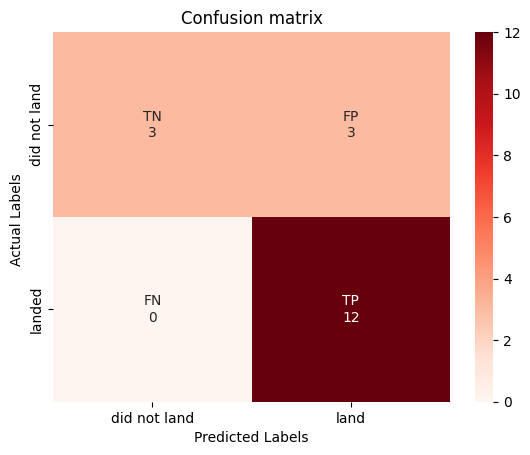

In [35]:

# Plotting confusion matrix with text annotations
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
# Defines a reusable function to plot a styled confusion matrix using true labels and model predictions
def plot_confusion_matrix(Y_test, yhat):
    # Calculates the raw counts for TP, FP, TN, and FN using scikit-learn
    cf_matrix = confusion_matrix(Y_test, yhat)
    
    # Creates a 2x2 text grid to map standard quadrant labels to the matrix
    text = np.array([['TN', 'FP'], ['FN','TP']])
    
    # Merges the quadrant labels and raw counts into string pairs
    formatted_text = (np.array(["{0}\n{1:0}".format(
        text, cf_matrix) for text, cf_matrix in zip(text.flatten(), cf_matrix.flatten())])).reshape(2, 2)

    # Draws a colored heatmap using Seaborn
    ax = sns.heatmap(cf_matrix, annot=formatted_text, fmt="", cmap='Reds')

    # Sets titles and axis labels
    ax.set_title('Confusion matrix')
    ax.set_xlabel('Predicted Labels')
    ax.set_ylabel('Actual Labels ')

    # Maps category names to the axes
    ax.xaxis.set_ticklabels(['did not land', 'land'])
    ax.yaxis.set_ticklabels(['did not land', 'landed'])

    # Renders and displays the final styled heatmap
    plt.show()

# Call the function replacing logreg_cv with the trained model name
y_pred = logreg_cv.predict(X_test) 
plot_confusion_matrix(Y_test, y_pred)


## TASK  6: Support Vector Machine


Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [36]:
# Defines a dictionary of hyperparameter ranges to test for a Support Vector Classifier (SVC)
parameters2 = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5), # Testing 5 logarithmic values for regularization strength, ranging from 0.001 to 1000.0
              'gamma':np.logspace(-3, 3, 5)} # Testing 5 logarithmic values for the kernel coefficient, controlling the radius of influence for data points
# Create the Support Vector Machine classification object
svm = SVC()


In [37]:
# Create the GridSearchCV object with cv = 10
from sklearn.model_selection import GridSearchCV
# Create the GridSearchCV object with cv = 10
svm_grid_search = GridSearchCV(estimator=svm, param_grid=parameters2, cv=10)

# 4. Fit the object to the training data to find the optimal hyperparameter combination
svm_cv = svm_grid_search.fit(X_train, Y_train)


In [93]:
# Output the tuning results
print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)


tuned hpyerparameters :(best parameters)  {'C': 1.0, 'gamma': 0.03162277660168379, 'kernel': 'sigmoid'}
accuracy : 0.8482142857142856


## TASK  7: Calculate the accuracy on the test data using SVM


Calculate the accuracy on the test data using the method <code>score</code>:


In [38]:
# Calculate the accuracy score on the test data
svm_score = svm_cv.score(X_test, Y_test)
print(f"Test Data Accuracy: {svm_score:.2f}")

Test Data Accuracy: 0.83


We can plot the confusion matrix


SVM Accuracy on test data: 0.83


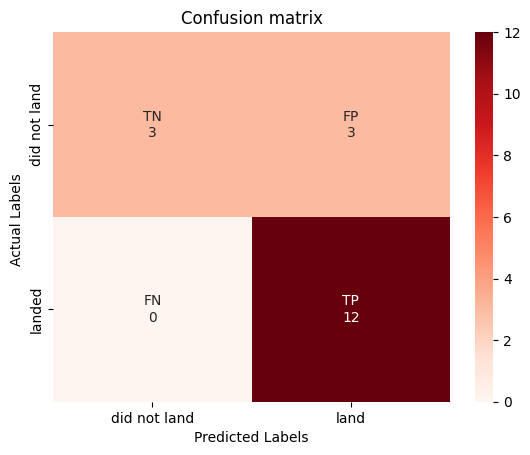

In [39]:
yhat_svm=svm_cv.predict(X_test)
svm_accuracy = svm_cv.score(X_test, Y_test)
print(f"SVM Accuracy on test data: {svm_accuracy:.2f}")
plot_confusion_matrix(Y_test,yhat_svm)

## TASK  8: Decision tree classifier


Create a decision tree classifier object then  create a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [40]:
#  Define the parameter grid for the Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
parameters3 = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [2*n for n in range(1, 10)],
     #'max_features': ['auto', 'sqrt'],
    'max_features': ['sqrt'],  # In recent versions of scikit-learn have officially removed 'auto' in decision trees. The parameter only accepts 'sqrt'
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}
#Create the decision tree classifier object
tree = DecisionTreeClassifier()


In [41]:
# Create the GridSearchCV object with cv = 10
grid_search = GridSearchCV(estimator=tree, param_grid=parameters3, cv=10)
#  Fit the object to the training data
tree_cv = grid_search.fit(X_train, Y_train)



In [42]:
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'criterion': 'entropy', 'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'splitter': 'random'}
accuracy : 0.8857142857142856


## TASK  9: Calculate the accuracy on the test data using Decision tree classifier


Calculate the accuracy of tree_cv on the test data using the method <code>score</code>:


In [43]:
# Calculate the accuracy score on the test data
tree_score = tree_cv.score(X_test, Y_test)
print(f"DecisionTree Test Data Accuracy: {tree_score:.2f}")



DecisionTree Test Data Accuracy: 0.83


We can plot the confusion matrix


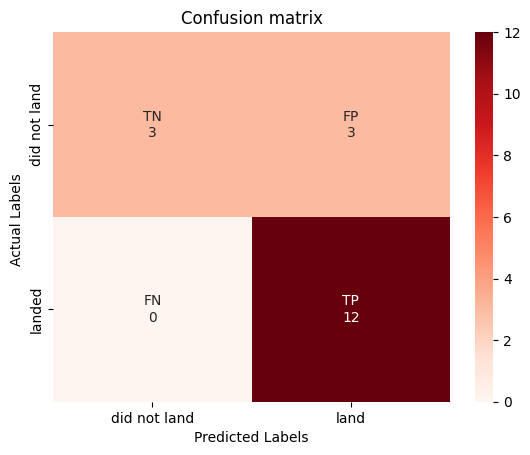

In [44]:
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## TASK  10: K-nearest neighbors


Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [49]:
#  Define the parameter grid for KNN
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]} # p=1 is Manhattan distance, p=2 is Euclidean distance
# Create the KNN classifier object
KNN = KNeighborsClassifier()

In [50]:
# Create the GridSearchCV object with cv = 10
grid_search = GridSearchCV(estimator=KNN, param_grid=parameters, cv=10)
#  Fit the object to the training data
knn_cv = grid_search.fit(X_train, Y_train)


In [51]:
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
accuracy : 0.8482142857142858


## TASK  11: Calculate the accuracy on the test data using K-nearest neighbors


Calculate the accuracy of knn_cv on the test data using the method <code>score</code>:


In [52]:
# Calculate the accuracy score on the test data
knn_score = knn_cv.score(X_test, Y_test)
print(f"Test Data Accuracy: {knn_score:.2f}")

Test Data Accuracy: 0.83


We can plot the confusion matrix


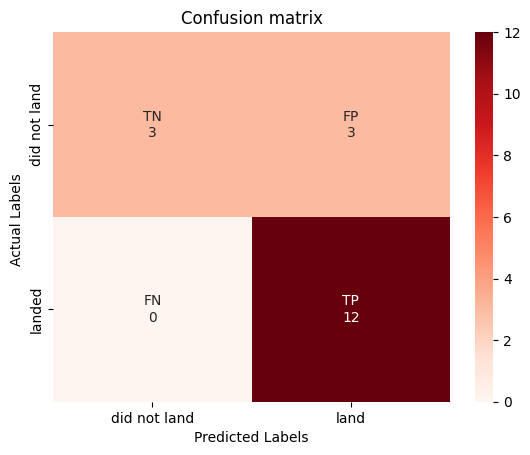

In [53]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## TASK  12: Find the best performance Model


Find the method performs best:


In [54]:
import pandas as pd

# Combine the results into a dictionary
scores_data = {
    'Model': ['Logistic Regression', 'Support Vector Machine', 'Decision Tree', 'K-Nearest Neighbors'],
    'Test Accuracy': [logreg_score, svm_score, tree_score, knn_score]
}

# Create a DataFrame and sort it by accuracy (highest first)
df_scores = pd.DataFrame(scores_data)
df_scores = df_scores.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

# Display the table
print(df_scores)

                    Model  Test Accuracy
0     Logistic Regression       0.833333
1  Support Vector Machine       0.833333
2           Decision Tree       0.833333
3     K-Nearest Neighbors       0.833333


In [55]:
# Combine the results into a dictionary, including cross-validation train scores
scores_data = {
    'Model': [
        'Logistic Regression', 
        'Support Vector Machine', 
        'Decision Tree', 
        'K-Nearest Neighbors'
    ],
    'Train Accuracy (CV)': [
        logreg_cv.best_score_, 
        svm_cv.best_score_, 
        tree_cv.best_score_, 
        knn_cv.best_score_
    ],
    'Test Accuracy': [
        logreg_score, 
        svm_score, 
        tree_score, 
        knn_score
    ]
}

# Create a DataFrame and sort it by Test Accuracy (highest first)
df_scores = pd.DataFrame(scores_data)
df_scores = df_scores.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

# Display the table
print(df_scores)

                    Model  Train Accuracy (CV)  Test Accuracy
0     Logistic Regression             0.846429       0.833333
1  Support Vector Machine             0.848214       0.833333
2           Decision Tree             0.885714       0.833333
3     K-Nearest Neighbors             0.848214       0.833333


In [56]:
#  Determine the best performing method from the top row of the above sorted DataFrame
best_method = df_scores.loc[0, 'Model']
best_test_score = df_scores.loc[0, 'Test Accuracy']
corresponding_train_score = df_scores.loc[0, 'Train Accuracy (CV)']

#  Print the best performing method with its corresponding scores
print(f"The best performing method is: {best_method}")
print(f"  - Test Accuracy:  {best_test_score:.4f}")
print(f"  - Train Accuracy: {corresponding_train_score:.4f}")

#  Check for a tie breaker
ties = df_scores[df_scores['Test Accuracy'] == best_test_score]
if len(ties) > 1:
    print(f"\nNote: There is a tie on Test Accuracy between: {', '.join(ties['Model'].tolist())}")
    # Ties are automatically resolved by choosing the one with the higher Train Accuracy
    best_tie_resolved = ties.sort_values(by='Train Accuracy (CV)', ascending=False).iloc[0]['Model']
    print(f"Tie-breaker resolved by highest Train Accuracy: Use {best_tie_resolved}")

The best performing method is: Logistic Regression
  - Test Accuracy:  0.8333
  - Train Accuracy: 0.8464

Note: There is a tie on Test Accuracy between: Logistic Regression, Support Vector Machine, Decision Tree, K-Nearest Neighbors
Tie-breaker resolved by highest Train Accuracy: Use Decision Tree


## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log--!>


<!--| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|--!>


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
